In [1]:
import sys 
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score ,StratifiedKFold
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

# load ML dataset
ml_dataset = pd.read_csv("../data/ml_dataset.csv")
print("Dataset shape : " , ml_dataset.shape)
print("Label distribution :")
print(ml_dataset["label"].value_counts())

Dataset shape :  (21, 13)
Label distribution :
label
1    11
0    10
Name: count, dtype: int64


In [2]:
# define feature column 
feature_cols = ["coint_pval" , "correlation" , "spread_std" , "half_life" , "hurst", "adf_pval", "spread_skew", "beta_stability"]

X = ml_dataset[feature_cols].copy()
y = ml_dataset["label"].copy()

# handle any infinite values from beta_stability 
X = X.replace([np.inf , -np.inf] , np.nan)
X = X.fillna(X.median())

print("Features shape : ", X.shape )
print("\nFeature ranges :")
print(X.describe().T[["min" ,"max" , "mean"]])

Features shape :  (21, 8)

Feature ranges :
                      min        max       mean
coint_pval       0.001777   0.048555   0.022984
correlation      0.816200   0.990900   0.911995
spread_std       2.188000  24.372600   8.892833
half_life       16.270000  31.500000  24.151429
hurst            0.364000   0.495600   0.435610
adf_pval         0.000000   0.000000   0.000000
spread_skew     -0.608400   0.902800   0.057510
beta_stability   0.009400  68.501200   4.448590


In [ ]:
# drop adf_pval - zero cariance , no information

In [4]:
feature_cols = ["coint_pval" , "correlation" , "spread_std" , "half_life" , "hurst","spread_skew", "beta_stability"]

X = ml_dataset[feature_cols].copy()
X = X.replace([np.inf , -np.inf] , np.nan)
X = X.fillna(X.median())

# scale features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled , columns = feature_cols)

print("Final features shape:" , X_scaled.shape)
print("\n After scaling = all features should be centered near 0 :")
print(X_scaled.describe().T[["min","max","mean"]])

Final features shape: (21, 7)

 After scaling = all features should be centered near 0 :
                     min       max          mean
coint_pval     -1.452911  1.751929 -9.516197e-17
correlation    -2.323984  1.914222 -2.194012e-15
spread_std     -1.154258  2.664890 -9.516197e-17
half_life      -1.894622  1.766528  2.907727e-17
hurst          -2.293877  1.921683 -7.771561e-16
spread_skew    -1.698504  2.156042  0.000000e+00
beta_stability -0.307801  4.441227 -3.436405e-17


In [5]:
# train Random Forest with cross-validation

rf = RandomForestClassifier(n_estimators = 100 , max_depth = 3 , min_samples_leaf= 2 , random_state=42)

# stratified 5-fold cross validation
cv = StratifiedKFold(n_splits= 5 , shuffle= True , random_state= 42)
cv_score = cross_val_score(rf , X_scaled , y, cv = cv , scoring="accuracy")

print("Cross-validation accuracy scores: " , cv_score.round(3))
print(f"Mean accuracy : {cv_score.mean():.3f}")
print(f"Std accuracy : {cv_score.std():.3f}")

Cross-validation accuracy scores:  [0.4  0.75 0.75 0.5  0.5 ]
Mean accuracy : 0.580
Std accuracy : 0.144


Feature Importance:
          feature  importance
0      spread_std    0.269244
1     correlation    0.141603
2       half_life    0.135386
3     spread_skew    0.133852
4           hurst    0.124191
5      coint_pval    0.110735
6  beta_stability    0.084989


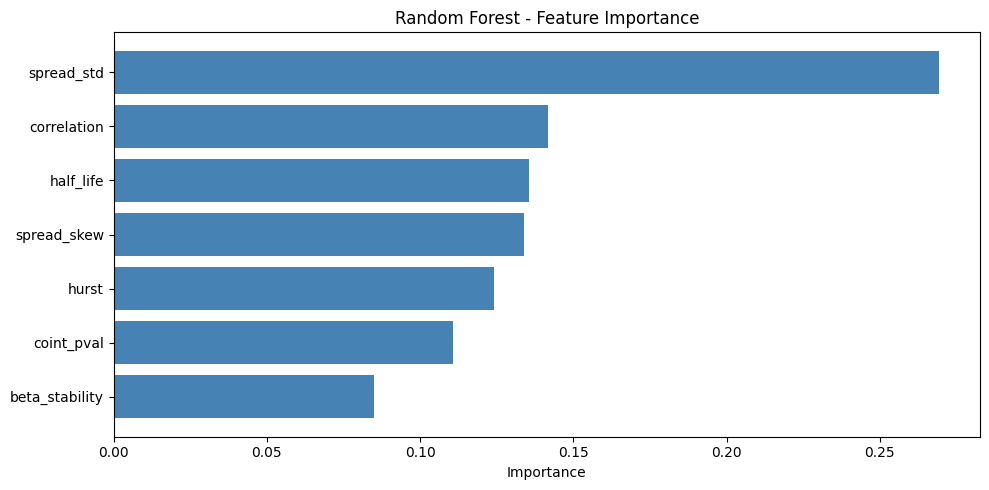

In [6]:
# train on full dataset to get feature importance 
rf.fit(X_scaled,y)

# feature importance 
importance_df = pd.DataFrame({
    "feature" : feature_cols,
    "importance" : rf.feature_importances_
}).sort_values("importance" , ascending=False).reset_index(drop =True)
print("Feature Importance:")
print(importance_df)

# plot 
fig , ax = plt.subplots(figsize = (10,5))
ax.barh(importance_df["feature"] , importance_df["importance"],color="steelblue")
ax.set_title("Random Forest - Feature Importance")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/feature_importance.png",dpi = 120)
plt.show()

In [7]:
from sklearn.model_selection import cross_val_predict

# get predictions via cross - validation
y_pred = cross_val_predict(rf , X_scaled , y ,cv = cv)

# confusion martrix
cm = confusion_matrix(y,y_pred)
print("Confusion Matrix :")
print(f"                    Predicted Bad     Predicted Good")
print(f"Actual Bad           {cm[0][0]}         {cm[0][1]}")
print(f"Actual Good          {cm[1][0]}         {cm[1][1]}")

print("\n Classification Report:")
print(classification_report(y,y_pred , target_names=["Bad Pair" , "Good Pair"]))

Confusion Matrix :
                    Predicted Bad     Predicted Good
Actual Bad           4         6
Actual Good          3         8

 Classification Report:
              precision    recall  f1-score   support

    Bad Pair       0.57      0.40      0.47        10
   Good Pair       0.57      0.73      0.64        11

    accuracy                           0.57        21
   macro avg       0.57      0.56      0.56        21
weighted avg       0.57      0.57      0.56        21



In [8]:
# get probablity scores for each pair
ml_dataset["rf_score"] = rf.predict_proba(X_scaled)[:,1]
ml_dataset["rf_predicted"] = rf.predict(X_scaled)

# compare Rf ranking vs p-value ranking 
comparison = ml_dataset[[
    "ticker_1" , "ticker_2","coint_pval" , "rf_score" , "test_sharpe" ,"label"
]].copy()

comparison["pval_rank"] = comparison["coint_pval"].rank()
comparison["rf_rank"] = comparison["rf_score"].rank(ascending=False)

comparison = comparison.sort_values("rf_score" ,ascending= False).reset_index(drop =True)

print("RF ranking vs P-value ranking:")
print(comparison[["ticker_1" , "ticker_2" , "rf_score" , "pval_rank" , "rf_rank" , "test_sharpe" , "test_sharpe" , "label"]])


RF ranking vs P-value ranking:
   ticker_1 ticker_2  rf_score  pval_rank  rf_rank  test_sharpe  test_sharpe  \
0        MA        V  0.795424       18.0      1.0       0.9809       0.9809   
1       CAT       DE  0.778341       16.0      2.0       0.5344       0.5344   
2         V      WMT  0.777626        3.0      3.0       0.1832       0.1832   
3       ABT       CL  0.769075       19.0      4.0       1.3207       1.3207   
4        MA      WMT  0.746302        2.0      5.0       0.3046       0.3046   
5       JNJ       KR  0.734100       17.0      6.0       0.1340       0.1340   
6     GOOGL      UNH  0.726848        4.0      7.0       0.6794       0.6794   
7       ABT      JNJ  0.725904        6.0      8.0       0.9742       0.9742   
8      AMZN       CL  0.695842       13.0      9.0       0.0252       0.0252   
9         C       GE  0.555146       10.0     10.0       0.5171       0.5171   
10     META      TGT  0.530135        1.0     11.0      -1.3989      -1.3989   
11       

In [9]:
import pickle 
# save model and scaler 
with open("../data/rf_model.pkl" , "wb") as f:
    pickle.dump(rf,f)

with open("../data/scaler.pkl" , "wb") as f:
    pickle.dump(scaler , f)

# save ranked pairs  
comparison.to_csv("../data/rf_ranked_pairs.csv" , index = False)

print("Model saved.")
print("Scaler saved.")
print("RF ranked pairs saved.")
print(f"\n top 3 RF pairs: {comparison[['ticker_1','ticker_2' ,'rf_score']].head(3).values}")

Model saved.
Scaler saved.
RF ranked pairs saved.

 top 3 RF pairs: [['MA' 'V' 0.7954242424242425]
 ['CAT' 'DE' 0.7783405483405484]
 ['V' 'WMT' 0.7776262626262627]]


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score

# use continous test_sharpe as target instead of binary level
y_reg = ml_dataset["test_sharpe"].copy()
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=2,
    random_state=42
)

# cross-val with regression scoring
from sklearn.model_selection import cross_val_score
cv_scores_reg = cross_val_score(rf_reg , X_scaled , y_reg , cv=5 , scoring = "r2")
print("R² scores across folds:", cv_scores_reg.round(3))
print(f"Mean R²  : {cv_scores_reg.mean():.3f}")
print(f"Std R²   : {cv_scores_reg.std():.3f}")

R² scores across folds: [-0.611 -0.196 -0.76   0.127 -0.171]
Mean R²  : -0.322
Std R²   : 0.321


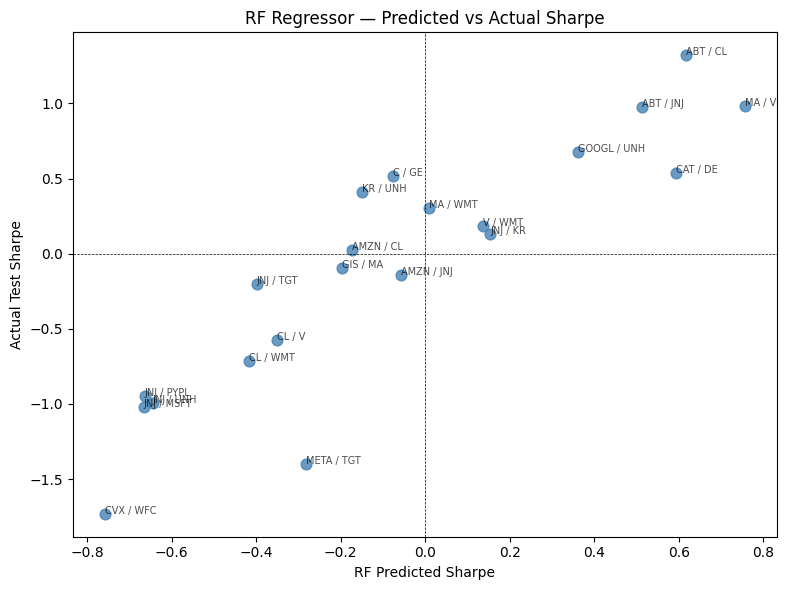

Top 10 RF Ranked Pairs:
  ticker_1 ticker_2  rf_predicted_sharpe  test_sharpe
0       MA        V             0.756293       0.9809
1      ABT       CL             0.616231       1.3207
2      CAT       DE             0.594310       0.5344
3      ABT      JNJ             0.512717       0.9742
4    GOOGL      UNH             0.360315       0.6794
5      JNJ       KR             0.153607       0.1340
6        V      WMT             0.137502       0.1832
7       MA      WMT             0.009270       0.3046
8     AMZN      JNJ            -0.056797      -0.1399
9        C       GE            -0.076051       0.5171


In [12]:
# train on full dataset 
rf_reg.fit(X_scaled , y_reg)

# predict scores for all pairs
ml_dataset["rf_predicted_sharpe"] = rf_reg.predict(X_scaled)

# scatter plot - predicted vs actual 
fig ,ax = plt.subplots(figsize=(8,6))
ax.scatter(ml_dataset["rf_predicted_sharpe"],ml_dataset["test_sharpe"] , color = "steelblue" , s= 60 , alpha = 0.8)

# label each point 
for _,row in ml_dataset.iterrows():
    ax.annotate(f"{row['ticker_1']} / {row['ticker_2']}" , (row["rf_predicted_sharpe"] , row["test_sharpe"]) , fontsize = 7 , alpha = 0.7)


ax.axhline(0,color="black" ,linewidth = 0.5, linestyle = "--")
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("RF Predicted Sharpe")
ax.set_ylabel("Actual Test Sharpe")
ax.set_title("RF Regressor — Predicted vs Actual Sharpe")
plt.tight_layout()
plt.savefig("../data/rf_regression_scatter.png", dpi=120)
plt.show()

# ranking  
ranking = ml_dataset[["ticker_1" , "ticker_2" , "rf_predicted_sharpe" , "test_sharpe"]].sort_values("rf_predicted_sharpe", ascending=False).reset_index(drop=True)

print("Top 10 RF Ranked Pairs:")
print(ranking.head(10))


In [15]:
# three baselines
# baselines 1 - p-value ranking  (lower is better)
ml_dataset["pval_rank"] = ml_dataset["coint_pval"].rank()

# baseline 2 - hurst ranking (lower is better)
ml_dataset["hurst_rank"] = ml_dataset["hurst"].rank()

# baseline 3 - historical sharpe (from training period)
from data_loader import load_prices , run_strategy_on_period

prices = load_prices()
train_prices = prices["2018-01-01" : "2021-12-31"]

train_sharpe = []
for _,row in ml_dataset.iterrows():
    result = run_strategy_on_period(train_prices , row["ticker_1"] , row["ticker_2"])
    train_sharpe.append(result["sharpe"] if result else 0)

ml_dataset["train_sharpe"] = train_sharpe
ml_dataset["train_sharpe_rank"] = ml_dataset["train_sharpe"].rank(ascending=False)
ml_dataset["rf_rank"] = ml_dataset["rf_predicted_sharpe"].rank(ascending=False)

# compare top 5 average test sharpe for each ranking method
def top_n_avg_sharpe(df , rank_col ,n=5):
    top = df.nsmallest(n,rank_col) 
    return round(top["test_sharpe"].mean() ,4)

print("Average test Sharpe oftop 5 pairs by ranking method:")
print(f"  P-value ranking        : {top_n_avg_sharpe(ml_dataset, 'pval_rank')}")
print(f"  Hurst ranking          : {top_n_avg_sharpe(ml_dataset, 'hurst_rank')}")
print(f"  Train Sharpe ranking   : {top_n_avg_sharpe(ml_dataset, 'train_sharpe_rank')}")
print(f"  RF Regressor ranking   : {top_n_avg_sharpe(ml_dataset, 'rf_rank')}")

Average test Sharpe oftop 5 pairs by ranking method:
  P-value ranking        : -0.0871
  Hurst ranking          : -0.3262
  Train Sharpe ranking   : -0.3814
  RF Regressor ranking   : 0.8979


In [16]:
import pickle

# save regressor and scaler
with open("../data/rf_regressor.pkl", "wb") as f:
    pickle.dump(rf_reg, f)

with open("../data/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

ml_dataset.to_csv("../data/ml_dataset_ranked.csv", index=False)

print("Saved RF regressor, scaler and ranked dataset.")
print("\nFinal ranking comparison:")
print(ml_dataset[["ticker_1", "ticker_2", 
                   "rf_predicted_sharpe", 
                   "test_sharpe"]].sort_values(
                   "rf_predicted_sharpe", 
                   ascending=False).head(10).to_string())

Saved RF regressor, scaler and ranked dataset.

Final ranking comparison:
   ticker_1 ticker_2  rf_predicted_sharpe  test_sharpe
17       MA        V             0.756293       0.9809
18      ABT       CL             0.616231       1.3207
15      CAT       DE             0.594310       0.5344
5       ABT      JNJ             0.512717       0.9742
3     GOOGL      UNH             0.360315       0.6794
16      JNJ       KR             0.153607       0.1340
2         V      WMT             0.137502       0.1832
1        MA      WMT             0.009270       0.3046
10     AMZN      JNJ            -0.056797      -0.1399
9         C       GE            -0.076051       0.5171
